# Computing Performance Analysis

This notebook visualizes computing time (latency) and peak RAM usage with respect to context length for different forecasting models.


In [6]:
import pandas as pd
from pyprojroot import here
import numpy as np
import matplotlib.pyplot as plt

from nutils import name_mask, colordict


In [33]:
# Load compute metrics data
df = pd.read_csv(here() / 'data/processed/compute_metrics2-c.csv')

# Display first few rows and data info
print("Data shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nUnique models:", df['model'].unique())
print("\nData preview:")
df.head(10)


Data shape: (85, 6)

Column names: ['model', 'featureset', 'context_length', 'latency', 'peak_ram_load_mb', 'total_peak_ram_mb']

Unique models: ['chronosboltbase' 'moirai2' 'sundial' 'timesfm' 'tirex']

Data preview:


,model,featureset,context_length,latency,peak_ram_load_mb,total_peak_ram_mb
0,chronosboltbase,u,8,22.976713,911.605469,1743.132812
1,chronosboltbase,u,16,1.327320,921.304688,1733.593750
2,chronosboltbase,u,24,1.536137,921.632812,1767.199219
3,chronosboltbase,u,48,1.442010,921.511719,1784.480469
4,chronosboltbase,u,72,2.068519,921.628906,1878.664062
5,chronosboltbase,u,96,2.389447,921.320312,1916.859375
6,chronosboltbase,u,120,3.180893,921.828125,2002.242188
7,chronosboltbase,u,144,3.190056,921.566406,2048.089844
8,chronosboltbase,u,168,3.986620,921.218750,2102.570312
9,chronosboltbase,u,336,6.660759,921.718750,2573.054688


In [34]:
# Define which context lengths to include in analysis
# Modify this list to control which context lengths appear in tables and plots
selected_context_lengths = [24, 96, 168, 336, 512, 720, 2048, 4096, 8760, 12840]

print("Available context lengths in data:", sorted(df['context_length'].unique()))
print("Selected context lengths:", selected_context_lengths)


Available context lengths in data: [8, 16, 24, 48, 72, 96, 120, 144, 168, 336, 512, 720, 1024, 2048, 2880, 4096, 8760, 12840]
Selected context lengths: [24, 96, 168, 336, 512, 720, 2048, 4096, 8760, 12840]


In [35]:
# Filter data to only selected context lengths
df_filtered = df[df['context_length'].isin(selected_context_lengths)].copy()

# Aggregate data by model and context length (handle duplicates by taking mean)
# Note: 'total_peak_ram_mb' column contains values in MiB (mebibytes), not MB
df_agg = df_filtered.groupby(['model', 'context_length']).agg({
    'latency': 'mean',
    'total_peak_ram_mb': 'mean'
}).reset_index()

# Apply model name mapping
model_name_map = {'chronosboltbase': 'chronos'}
df_agg['model'] = df_agg['model'].replace(model_name_map)

# Pivot data for easier plotting
latency_pivot = df_agg.pivot(index='context_length', columns='model', values='latency')
ram_pivot = df_agg.pivot(index='context_length', columns='model', values='total_peak_ram_mb')

print("Models included:", latency_pivot.columns.tolist())
print("Context lengths in analysis:", sorted(df_agg['context_length'].unique()))


Models included: ['chronos', 'moirai2', 'sundial', 'timesfm', 'tirex']
Context lengths in analysis: [24, 96, 168, 336, 512, 720, 2048, 4096, 8760, 12840]


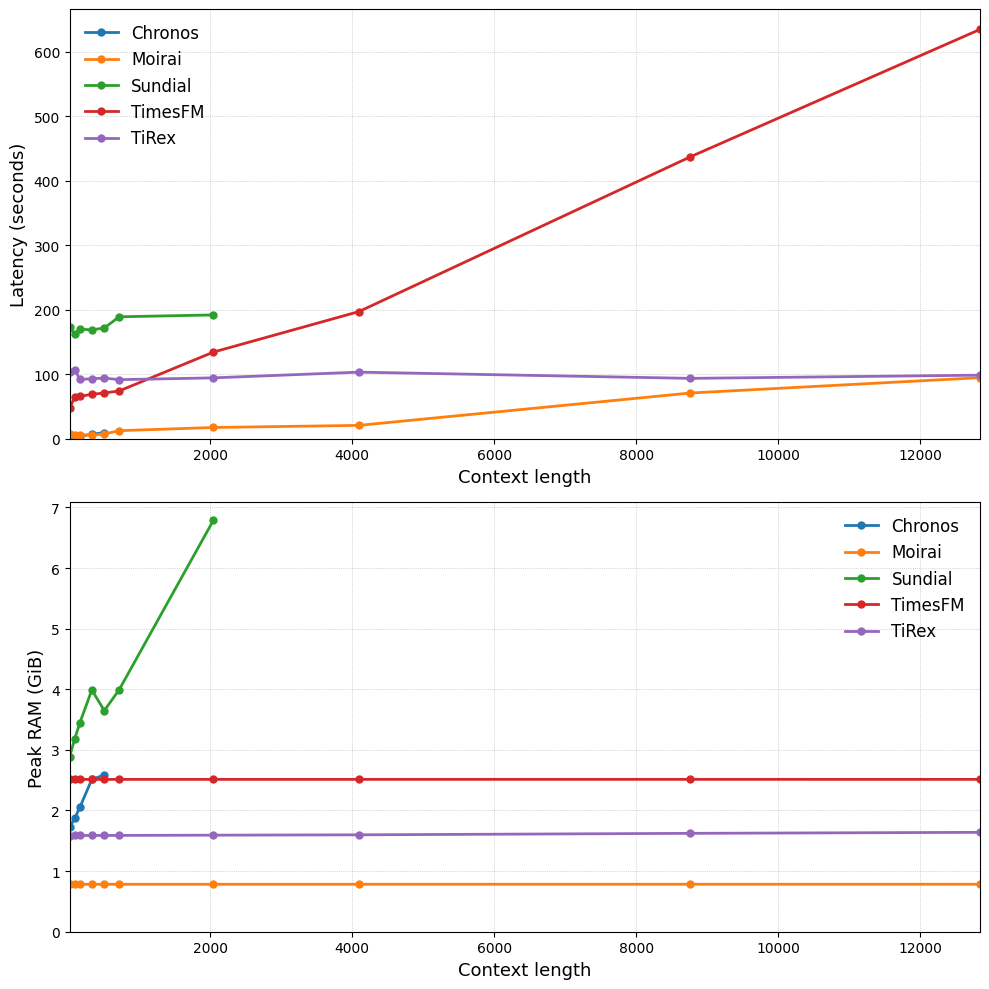

In [36]:
# Create a two-panel figure showing latency and RAM usage
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

# Model display names
display_names = {
    'chronos': 'Chronos',
    'moirai2': 'Moirai',
    'sundial': 'Sundial',
    'timesfm': 'TimesFM',
    'tirex': 'TiRex'
}

# Plot 1: Latency vs Context Length
for i, model in enumerate(latency_pivot.columns):
    data = latency_pivot[model].dropna()
    if len(data) > 0:
        x = data.index.astype(int)
        y = data.values
        color = plt.cm.tab10(i % 10)
        display_name = display_names.get(model, model.capitalize())
        ax1.plot(x, y, label=display_name, color=color, marker='o', markersize=5, linewidth=2)

ax1.legend(frameon=False, loc='best', fontsize=12)
ax1.set_ylabel('Latency (seconds)', fontsize=13)
ax1.set_xlabel('Context length', fontsize=13)
ax1.grid(lw=0.5, ls=':', color='gray', alpha=0.6)
ax1.set_ylim(bottom=0)
ax1.margins(x=0.00)
ax1.set_title('', fontsize=12, pad=15)

# Plot 2: Peak RAM vs Context Length
for i, model in enumerate(ram_pivot.columns):
    data = ram_pivot[model].dropna()
    if len(data) > 0:
        x = data.index.astype(int)
        y = data.values / 1024  # Convert MiB to GiB
        color = plt.cm.tab10(i % 10)
        display_name = display_names.get(model, model.capitalize())
        ax2.plot(x, y, label=display_name, color=color, marker='o', markersize=5, linewidth=2)

ax2.legend(frameon=False, loc='best', fontsize=12)
ax2.set_ylabel('Peak RAM (GiB)', fontsize=13)
ax2.set_xlabel('Context length', fontsize=13)
ax2.grid(lw=0.5, ls=':', color='gray', alpha=0.6)
ax2.set_ylim(bottom=0)
ax2.margins(x=0.0)
#ax2.set_title('Peak RAM Usage vs Context Length', fontsize=14, pad=15)

plt.tight_layout()
# plt.savefig(here() / 'output/plots/compute_performance.jpg', dpi=300, bbox_inches='tight')
plt.show()


In [37]:
# Summary statistics
print("=" * 60)
print("LATENCY SUMMARY (seconds)")
print("=" * 60)
print("\nLatency by model (mean ± std):")
for model in df_agg['model'].unique():
    model_data = df_agg[df_agg['model'] == model]['latency']
    display_name = display_names.get(model, model.capitalize())
    print(f"{display_name:12s}: {model_data.mean():6.2f} ± {model_data.std():6.2f}")

print("\n" + "=" * 60)
print("PEAK RAM SUMMARY (GiB)")
print("=" * 60)
print("\nPeak RAM by model (mean ± std):")
for model in df_agg['model'].unique():
    model_data = df_agg[df_agg['model'] == model]['total_peak_ram_mb'] / 1024  # Convert MiB to GiB
    display_name = display_names.get(model, model.capitalize())
    print(f"{display_name:12s}: {model_data.mean():6.2f} ± {model_data.std():6.2f}")


LATENCY SUMMARY (seconds)

Latency by model (mean ± std):
Chronos     :   4.81 ±   3.26
Moirai      :  24.58 ±  31.58
Sundial     : 175.13 ±  11.11
TimesFM     : 179.46 ± 198.56
TiRex       :  96.99 ±   5.59

PEAK RAM SUMMARY (GiB)

Peak RAM by model (mean ± std):
Chronos     :   2.15 ±   0.38
Moirai      :   0.78 ±   0.00
Sundial     :   3.99 ±   1.30
TimesFM     :   2.51 ±   0.00
TiRex       :   1.60 ±   0.02


In [38]:
# Create academic-style table with computing performance metrics
# Prepare data for table
table_data = []

for model in sorted(df_agg['model'].unique()):
    model_df = df_agg[df_agg['model'] == model].sort_values('context_length')
    
    row = {
        'Model': display_names.get(model, model.capitalize()),
        'Min CL': int(model_df['context_length'].min()),
        'Max CL': int(model_df['context_length'].max()),
        'Latency (s)': f"{model_df['latency'].mean():.1f} ± {model_df['latency'].std():.1f}",
        'RAM (GiB)': f"{(model_df['total_peak_ram_mb'].mean() / 1024):.2f} ± {(model_df['total_peak_ram_mb'].std() / 1024):.2f}",
        'Min Latency (s)': f"{model_df['latency'].min():.1f}",
        'Max Latency (s)': f"{model_df['latency'].max():.1f}",
        'Min RAM (GiB)': f"{(model_df['total_peak_ram_mb'].min() / 1024):.2f}",
        'Max RAM (GiB)': f"{(model_df['total_peak_ram_mb'].max() / 1024):.2f}"
    }
    table_data.append(row)

performance_table = pd.DataFrame(table_data)

print("\n" + "=" * 100)
print("COMPUTING PERFORMANCE TABLE")
print("=" * 100)
print("\nCL = Context Length (hours)")
print("Latency and RAM values shown as mean ± std across all tested context lengths\n")
print(performance_table.to_string(index=False))
print("=" * 100)



COMPUTING PERFORMANCE TABLE

CL = Context Length (hours)
Latency and RAM values shown as mean ± std across all tested context lengths

  Model  Min CL  Max CL   Latency (s)   RAM (GiB) Min Latency (s) Max Latency (s) Min RAM (GiB) Max RAM (GiB)
Chronos      24     512     4.8 ± 3.3 2.15 ± 0.38             1.5             9.5          1.73          2.59
 Moirai      24   12840   24.6 ± 31.6 0.78 ± 0.00             5.2            94.6          0.78          0.78
Sundial      24    2048  175.1 ± 11.1 3.99 ± 1.30           161.7           191.9          2.89          6.79
TimesFM      24   12840 179.5 ± 198.6 2.51 ± 0.00            48.2           634.9          2.51          2.51
  TiRex      24   12840    97.0 ± 5.6 1.60 ± 0.02            91.5           106.8          1.58          1.64


In [39]:
# TABLE 1: Latency by Context Length
latency_table = df_agg.pivot(index='context_length', columns='model', values='latency').round(1)

# Rename columns for display
latency_table.columns = [display_names.get(col, col.capitalize()) for col in latency_table.columns]
latency_table.index.name = 'Context Length'

# Sort columns alphabetically
latency_table = latency_table[sorted(latency_table.columns)]

print("\n" + "=" * 100)
print("TABLE 1: LATENCY BY CONTEXT LENGTH (seconds)")
print("=" * 100)
print(latency_table.to_string(na_rep='—'))  # Use em dash for missing values
print("=" * 100)

# Display as styled DataFrame for better visualization
latency_table.style.set_caption("Latency (seconds) for each model at different context lengths").format("{:.1f}", na_rep='—')



TABLE 1: LATENCY BY CONTEXT LENGTH (seconds)
                Chronos  Moirai  Sundial  TiRex  TimesFM
Context Length                                          
24                  1.5     6.5    173.0  103.5     48.2
96                  2.4     5.2    161.7  106.8     63.9
168                 4.0     5.6    169.8   91.8     65.6
336                 6.7     5.8    168.8   92.9     68.8
512                 9.5     7.2    171.7   94.0     70.8
720                   —    12.3    189.0   91.5     73.9
2048                  —    17.3    191.9   94.3    134.3
4096                  —    20.6        —  103.2    197.1
8760                  —    70.8        —   93.5    437.1
12840                 —    94.6        —   98.5    634.9


,Chronos,Moirai,Sundial,TiRex,TimesFM
Context Length,,,,,
24,1.5,6.5,173.0,103.5,48.2
96,2.4,5.2,161.7,106.8,63.9
168,4.0,5.6,169.8,91.8,65.6
336,6.7,5.8,168.8,92.9,68.8
512,9.5,7.2,171.7,94.0,70.8
720,—,12.3,189.0,91.5,73.9
2048,—,17.3,191.9,94.3,134.3
4096,—,20.6,—,103.2,197.1
8760,—,70.8,—,93.5,437.1


In [40]:
# TABLE 2: Peak RAM by Context Length
ram_table = (df_agg.pivot(index='context_length', columns='model', values='total_peak_ram_mb') / 1024).round(2)

# Rename columns for display
ram_table.columns = [display_names.get(col, col.capitalize()) for col in ram_table.columns]
ram_table.index.name = 'Context Length'

# Sort columns alphabetically
ram_table = ram_table[sorted(ram_table.columns)]

print("\n" + "=" * 100)
print("TABLE 2: PEAK RAM BY CONTEXT LENGTH (GiB)")
print("=" * 100)
print(ram_table.to_string(na_rep='—'))  # Use em dash for missing values
print("=" * 100)

# Display as styled DataFrame for better visualization
ram_table.style.set_caption("Peak RAM (GiB) for each model at different context lengths").format("{:.2f}", na_rep='—')



TABLE 2: PEAK RAM BY CONTEXT LENGTH (GiB)
                Chronos  Moirai  Sundial  TiRex  TimesFM
Context Length                                          
24                 1.73    0.78     2.89   1.58     2.51
96                 1.87    0.78     3.18   1.59     2.51
168                2.05    0.78     3.45   1.59     2.51
336                2.51    0.78     3.99   1.59     2.51
512                2.59    0.78     3.65   1.59     2.51
720                   —    0.78     3.99   1.59     2.51
2048                  —    0.78     6.79   1.59     2.51
4096                  —    0.78        —   1.60     2.51
8760                  —    0.78        —   1.62     2.51
12840                 —    0.78        —   1.64     2.51


,Chronos,Moirai,Sundial,TiRex,TimesFM
Context Length,,,,,
24,1.73,0.78,2.89,1.58,2.51
96,1.87,0.78,3.18,1.59,2.51
168,2.05,0.78,3.45,1.59,2.51
336,2.51,0.78,3.99,1.59,2.51
512,2.59,0.78,3.65,1.59,2.51
720,—,0.78,3.99,1.59,2.51
2048,—,0.78,6.79,1.59,2.51
4096,—,0.78,—,1.60,2.51
8760,—,0.78,—,1.62,2.51


In [48]:
# Export LATENCY table to LaTeX
latex_latency = latency_table.to_latex(
    caption='Computing time (latency) in seconds for each forecasting model across different context lengths. '
            'Missing values indicate the model does not support that context length.',
    label='tab:latency_context',
    position='htbp',
    float_format="%.1f",
    column_format='r' + 'r' * len(latency_table.columns),
    na_rep='{---}',  # Use LaTeX em-dash for missing values
    escape=False
)

print("\n" + "=" * 100)
print("LaTeX TABLE 1: LATENCY (copy this into your paper)")
print("=" * 100)
print(latex_latency)
print("=" * 100)

# Optionally save to file
with open(here() / 'output/tables/latency_by_context.tex', 'w') as f:
    f.write(latex_latency)



LaTeX TABLE 1: LATENCY (copy this into your paper)
\begin{table}[htbp]
\centering
\caption{Computing time (latency) in seconds for each forecasting model across different context lengths. Missing values indicate the model does not support that context length.}
\label{tab:latency_context}
\begin{tabular}{rrrrrr}
\toprule
{} &  Chronos &  Moirai &  Sundial &  TiRex &  TimesFM \\
Context Length &          &         &          &        &          \\
\midrule
24             &      1.5 &     6.5 &    173.0 &  103.5 &     48.2 \\
96             &      2.4 &     5.2 &    161.7 &  106.8 &     63.9 \\
168            &      4.0 &     5.6 &    169.8 &   91.8 &     65.6 \\
336            &      6.7 &     5.8 &    168.8 &   92.9 &     68.8 \\
512            &      9.5 &     7.2 &    171.7 &   94.0 &     70.8 \\
720            &    {---} &    12.3 &    189.0 &   91.5 &     73.9 \\
2048           &    {---} &    17.3 &    191.9 &   94.3 &    134.3 \\
4096           &    {---} &    20.6 &    {---} &  

/tmp/ipykernel_19823/2165596187.py:2: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex_latency = latency_table.to_latex(


## Feature Subset Analysis

Analysis of computing performance across different feature subsets (individual covariates).


In [7]:
# Load the feature subset compute metrics data
df_subsets = pd.read_csv(here() / 'data/processed/compute_metrics-a.csv')

# Display basic info
print("Data shape:", df_subsets.shape)
print("\nColumn names:", df_subsets.columns.tolist())
print("\nUnique models:", df_subsets['model'].unique())
print("\nData preview:")
df_subsets.head(15)


Data shape: (39, 6)

Column names: ['model', 'subsets', 'context_length', 'latency', 'peak_ram_load_mb', 'total_peak_ram_mb']

Unique models: ['moirai2']

Data preview:


,model,subsets,context_length,latency,peak_ram_load_mb,total_peak_ram_mb
0,moirai2,"('Trends', 'Events', 'Website_visits', 'Beds',...",256,43.347132,44.070312,1033.587402
1,moirai2,Trends,256,5.105098,1033.587402,53.481445
2,moirai2,Events,256,5.201819,96.265625,53.497559
3,moirai2,Website_visits,256,5.166043,96.265625,53.875977
4,moirai2,Beds,256,5.315284,96.765625,68.441895
5,moirai2,Calendar,256,5.331862,96.765625,56.466309
6,moirai2,Holiday_name,256,5.347118,96.765625,63.920410
7,moirai2,Hour,256,5.511572,96.265625,70.826660
8,moirai2,Month,256,5.335130,96.765625,59.626465
9,moirai2,TA,256,5.453418,96.765625,84.418457


In [8]:
# Process subsets: rename "all subsets combined" to "All"
df_individual = df_subsets.copy()

# Create a clean subset name - if it contains parentheses, it's "All", otherwise keep as-is
df_individual['subset_name'] = df_individual['subsets'].apply(
    lambda x: 'All' if '(' in str(x) else x
)

print("Subsets found:", sorted(df_individual['subset_name'].unique()))
print("\nContext lengths:", sorted(df_individual['context_length'].unique()))
print("\nData shape:", df_individual.shape)


Subsets found: ['All', 'Beds', 'Calendar', 'Events', 'Holiday_name', 'Hour', 'Month', 'TA', 'Traffic', 'Trends', 'Weather', 'Website_visits', 'Weekday']

Context lengths: [256, 512, 1024]

Data shape: (39, 7)


In [3]:
# TABLE 3: Latency by Feature Subset
latency_subset_table = df_individual.pivot(
    index='context_length', 
    columns='subset_name', 
    values='latency'
).round(1)

latency_subset_table.index.name = 'Context Length'
latency_subset_table.columns.name = None  # Remove the column axis name for clean LaTeX output

# Sort columns: "All" first, then alphabetically
columns_sorted = ['All'] + sorted([col for col in latency_subset_table.columns if col != 'All'])
latency_subset_table = latency_subset_table[columns_sorted]

print("\n" + "=" * 120)
print("TABLE 3: LATENCY BY FEATURE SUBSET (seconds)")
print("=" * 120)
print(latency_subset_table.to_string(na_rep='—'))
print("=" * 120)

latency_subset_table


NameError: name 'df_individual' is not defined

In [9]:
# TABLE 4: Peak RAM by Feature Subset
ram_subset_table = (df_individual.pivot(
    index='context_length', 
    columns='subset_name', 
    values='total_peak_ram_mb'
) / 1024).round(2)  # Convert MiB to GiB

ram_subset_table.index.name = 'Context Length'
ram_subset_table.columns.name = None  # Remove the column axis name for clean LaTeX output                                                                      

# Sort columns: "All" first, then alphabetically
columns_sorted = ['All'] + sorted([col for col in ram_subset_table.columns if col != 'All'])                                                                    
ram_subset_table = ram_subset_table[columns_sorted]

print("\n" + "=" * 120)
print("TABLE 4: PEAK RAM BY FEATURE SUBSET (GiB)")
print("=" * 120)
print(ram_subset_table.to_string(na_rep='—'))
print("=" * 120)

ram_subset_table



TABLE 4: PEAK RAM BY FEATURE SUBSET (GiB)
                  All  Beds  Calendar  Events  Holiday_name  Hour  Month    TA  Traffic  Trends  Weather  Website_visits  Weekday
Context Length                                                                                                                   
256              1.01  0.07      0.06    0.05          0.06  0.07   0.06  0.08     0.14    0.05     0.06            0.05     0.05
512              3.64  0.11      0.06    0.05          0.08  0.11   0.07  0.17     0.39    0.05     0.08            0.05     0.06
1024            13.93  0.25      0.09    0.05          0.16  0.26   0.11  0.49     1.36    0.05     0.14            0.06     0.08


,All,Beds,Calendar,Events,Holiday_name,Hour,Month,TA,Traffic,Trends,Weather,Website_visits,Weekday
Context Length,,,,,,,,,,,,,
256,1.01,0.07,0.06,0.05,0.06,0.07,0.06,0.08,0.14,0.05,0.06,0.05,0.05
512,3.64,0.11,0.06,0.05,0.08,0.11,0.07,0.17,0.39,0.05,0.08,0.05,0.06
1024,13.93,0.25,0.09,0.05,0.16,0.26,0.11,0.49,1.36,0.05,0.14,0.06,0.08


In [22]:
# Export LATENCY BY SUBSET table to LaTeX
latex_latency_subset = latency_subset_table.to_latex(
    caption='Computing time (latency) in seconds for different feature subsets across context lengths (Moirai model). '
            '"All" represents all covariates combined, while other columns represent individual covariate features.',
    label='tab:latency_subset',
    position='htbp',
    float_format="%.1f",
    column_format='r' + 'r' * len(latency_subset_table.columns),
    na_rep='{---}',
    escape=False
)

# Fix the LaTeX output by removing the unwanted "subset_name" header row
# Replace the line that starts with "subset_name" with just the column headers
lines = latex_latency_subset.split('\n')
for i, line in enumerate(lines):
    if line.startswith('subset_name &') or line.startswith('{} &'):
        # Remove "subset_name &" or "{} &" from the beginning
        if 'subset_name &' in line:
            lines[i] = line.replace('subset_name &', '', 1).strip()
        elif line.startswith('{} &'):
            lines[i] = line.replace('{} &', '', 1).strip()
latex_latency_subset = '\n'.join(lines)

print("\n" + "=" * 120)
print("LaTeX TABLE 3: LATENCY BY FEATURE SUBSET (copy this into your paper)")
print("=" * 120)
print(latex_latency_subset)
print("=" * 120)

# Save to file
with open(here() / 'output/tables/latency_by_subset.tex', 'w') as f:
    f.write(latex_latency_subset)



LaTeX TABLE 3: LATENCY BY FEATURE SUBSET (copy this into your paper)
\begin{table}[htbp]
\centering
\caption{Computing time (latency) in seconds for different feature subsets across context lengths (Moirai model). "All" represents all covariates combined, while other columns represent individual covariate features.}
\label{tab:latency_subset}
\begin{tabular}{rrrrrrrrrrrrrr}
\toprule
All &  Beds &  Calendar &  Events &  Holiday_name &  Hour &  Month &   TA &  Traffic &  Trends &  Weather &  Website_visits &  Weekday \\
Context Length &       &       &           &         &               &       &        &      &          &         &          &                 &          \\
\midrule
256            &  43.3 &   5.3 &       5.3 &     5.2 &           5.3 &   5.5 &    5.3 &  5.5 &      7.4 &     5.1 &      7.3 &             5.2 &      5.3 \\
512            & 110.3 &   5.6 &       5.4 &     5.2 &           5.4 &   5.8 &    5.4 &  7.8 &     14.1 &     5.2 &      7.5 &             5.2 &      5.

/tmp/ipykernel_23598/392874908.py:2: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex_latency_subset = latency_subset_table.to_latex(


In [ ]:
# Export PEAK RAM BY SUBSET table to LaTeX
latex_ram_subset = ram_subset_table.to_latex(
    caption='Peak RAM usage in MiB for different feature subsets across context lengths for Moirai model. "All" represents all covariates combined, while other columns represent covariate subsets.',
    label='tab:ram_subset',
    position='htbp',
    float_format="%.6f",
    column_format='r' + 'r' * len(ram_subset_table.columns),
    na_rep='{---}',
    escape=False
)

# Fix the LaTeX output by removing the unwanted "{}" or "subset_name" header row
lines = latex_ram_subset.split('\n')
for i, line in enumerate(lines):
    if line.startswith('subset_name &') or line.startswith('{} &'):
        # Remove "subset_name &" or "{} &" from the beginning
        if 'subset_name &' in line:
            lines[i] = line.replace('subset_name &', '', 1).strip()
        elif line.startswith('{} &'):
            lines[i] = line.replace('{} &', '', 1).strip()
latex_ram_subset = '\n'.join(lines)

print("\n" + "=" * 120)
print("LaTeX TABLE 4: PEAK RAM BY FEATURE SUBSET (copy this into your paper)")
print("=" * 120)
print(latex_ram_subset)
print("=" * 120)

# Save to file
with open(here() / 'output/tables/ram_by_subset.tex', 'w') as f:
    f.write(latex_ram_subset)



LaTeX TABLE 4: PEAK RAM BY FEATURE SUBSET (copy this into your paper)
\begin{table}[htbp]
\centering
\caption{Peak RAM usage in MiB for different feature subsets across context lengths for Moirai model. "All" represents all covariates combined, while other columns represent covariate subsets.}
\label{tab:ram_subset}
\begin{tabular}{rrrrrrrrrrrrrr}
\toprule
All &  Beds &  Calendar &  Events &  Holiday_name &  Hour &  Month &    TA &  Traffic &  Trends &  Weather &  Website_visits &  Weekday \\
Context Length &        &       &           &         &               &       &        &       &          &         &          &                 &          \\
\midrule
256            &  1.010 & 0.070 &     0.060 &   0.050 &         0.060 & 0.070 &  0.060 & 0.080 &    0.140 &   0.050 &    0.060 &           0.050 &    0.050 \\
512            &  3.640 & 0.110 &     0.060 &   0.050 &         0.080 & 0.110 &  0.070 & 0.170 &    0.390 &   0.050 &    0.080 &           0.050 &    0.060 \\
1024           

/tmp/ipykernel_14730/1037525053.py:2: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  latex_ram_subset = ram_subset_table.to_latex(


In [24]:
# Export PEAK RAM table to LaTeX
latex_ram = ram_table.to_latex(
    caption='Peak RAM usage in GiB for each forecasting model across different context lengths.',
    label='tab:ram_context',
    position='htbp',
    float_format="%.2f",
    column_format='r' + 'r' * len(ram_table.columns),
    na_rep='{---}',  # Use LaTeX em-dash for missing values
    escape=False
)

print("\n" + "=" * 100)
print("LaTeX TABLE 2: PEAK RAM (copy this into your paper)")
print("=" * 100)
print(latex_ram)
print("=" * 100)

# Optionally save to file
with open(here() / 'output/tables/ram_by_context.tex', 'w') as f:
    f.write(latex_ram)


NameError: name 'ram_table' is not defined